In [1]:
### Setup to equivalently run in colab or run locally ###
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB: # setup for colab

    # Initialize widget
    from google.colab import output
    output.enable_custom_widget_manager()

    # Colab-specific widget support
    !pip install -U ipympl --quiet

    # Clone repo and cd into it to behave like running locally
    %cd /content
    if not os.path.exists("arc_zte"):
      print("Cloning repo")
      !git clone https://github.com/mikgroup/arc_zte.git
    %cd /content/arc_zte
    # Pull in case repo was already cloned
    !git pull

    # Download data from OSF
    !pip install osfclient --quiet
    if not os.path.exists('data_for_arczte_paper/ge_phantom'):
      print("Downloading data from OSF. This will take ~5min..")
      PROJECT_ID = 'x3j8s'
      !osf -p {PROJECT_ID} clone ./
      !mv /content/arc_zte/osfstorage/* ./
      !rm -rf /content/arc_zte/osfstorage

    # Setup env
    !pip install -r requirements.txt --quiet
      
    # Setup matplotlib mode
    try:
      %matplotlib widget
    except:
      %matplotlib inline
      print('Running inline mode')

elif not IN_COLAB: # setup for running locally
    
    from zte_recon.util.os_util import set_gpu 
    
    # Set local data path (download from DOI linked on README)
    local_data_path = './data_for_arczte_paper/ge_phantom/'
    if not os.path.exists(local_data_path):
        raise NotADirectoryError('Data directory not found!')
   
    # Local Jupyter 
    %matplotlib notebook

    # Set GPU device for recon or -1 for CPU.
    device_num = 0
    set_gpu(device_num)

In [2]:
import numpy as np
import sigpy as sp
import matplotlib.pyplot as plt
import sigpy.plot as pl
import glob
from tqdm import tqdm

from zte_recon.data_zte import Data_Arc_ZTE
from zte_recon.traj_zte import Traj_ArcZTE_from_kacq, Traj_RadialZTE_from_kacq, Traj_CalcPhyllo_ZTE
from zte_recon.recon_gridding import recon_adjoint_postcomp_coilbycoil
from zte_recon.arc_zte_traj import read_params_from_kacq
from zte_recon.plot import plot_coherence_pathways_from_coords, plot_spokes_temporal_color, plot_3d_axes
from zte_recon.psf import calc_psf_coords, sidelobe_to_peak_ratio

from arc_zte_sim.metrics import cov_uniformity_metric

/home/shreya/cont-slew-zte/venv/lib/python3.10/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
libcudnn.so.8: cannot open shared object file: No such file or directory
  warnings.warn(


In [13]:
# Set DEMO_MODE to False if not running as a demo
# or True if just want to test if cells will run without failing
DEMO_MODE = True

if DEMO_MODE:
    img_shape = [64,64,64]
    device_num = -1 # set to CPU, no GPU dependency
    nPts_covg_metric = 200 # fewer test points for U
    nPtsPerSpoke = 64 # fewer points per spoke
else:
    img_shape = [256,256,256]
    nPts_covg_metric = 10000
    nPtsPerSpoke = None

# Reconstruction parameters
FOV_scale = 1
FOV_scale_dir = [1,1,1]
rBW = 31.25e3

# To account for coil ringing, drop extra points at spoke start
ndrop_ROpts = 1 

# Figure 3

## Load phantom data

In [14]:
# Golden angle rotations of Arc-ZTE segments
seg_rot_file = './rot_txt_files/seg_golden3d_rotMats.txt'

################

### Furthest theta_i's scheme - purely maximize coverage
h5_save_dir = local_data_path + 'furthest_angle53/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte*')[-1]
acq_params = read_params_from_kacq(kacq_file)

Furthest_thetas_data = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Furthest_thetas_data.gradient_corr(-0.25)

################

### Random theta_i's scheme - choose randomly
h5_save_dir = local_data_path + 'random_angle53/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte*')[-1]
acq_params = read_params_from_kacq(kacq_file)

Random_thetas_data = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Random_thetas_data.gradient_corr(-0.25)

################

### Optimization-based scheme to choose theta_i's
h5_save_dir = local_data_path + 'optim_angle53/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte')[-1]
acq_params = read_params_from_kacq(kacq_file)

Optim_thetas_data = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Optim_thetas_data.gradient_corr(-0.25)

Loading ksp from h5 dir: ./data_for_arczte_paper/ge_phantom/furthest_angle53/
Applied gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/ge_phantom/random_angle53/
Applied gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/ge_phantom/optim_angle53/
Applied gradient delay correction of -0.25


## Coverage uniformity metrics

In [15]:
nSpk = Optim_thetas_data.spokes_per_seg

print(f"Furthest thetas: U = {cov_uniformity_metric(Furthest_thetas_data.coord_radial_spokes[0:nSpk, -1], n=nPts_covg_metric):.2e}")
print(f"Random thetas: U = {cov_uniformity_metric(Random_thetas_data.coord_radial_spokes[0:nSpk, -1], n=nPts_covg_metric):.2e}")
print(f"Optimized thetas: U = {cov_uniformity_metric(Optim_thetas_data.coord_radial_spokes[0:nSpk, -1], n=nPts_covg_metric):.2e}")

Furthest thetas: U = 1.02e+00
Random thetas: U = 1.00e+00
Optimized thetas: U = 1.01e+00


## Plot coherence pathways

<IPython.core.display.Javascript object>


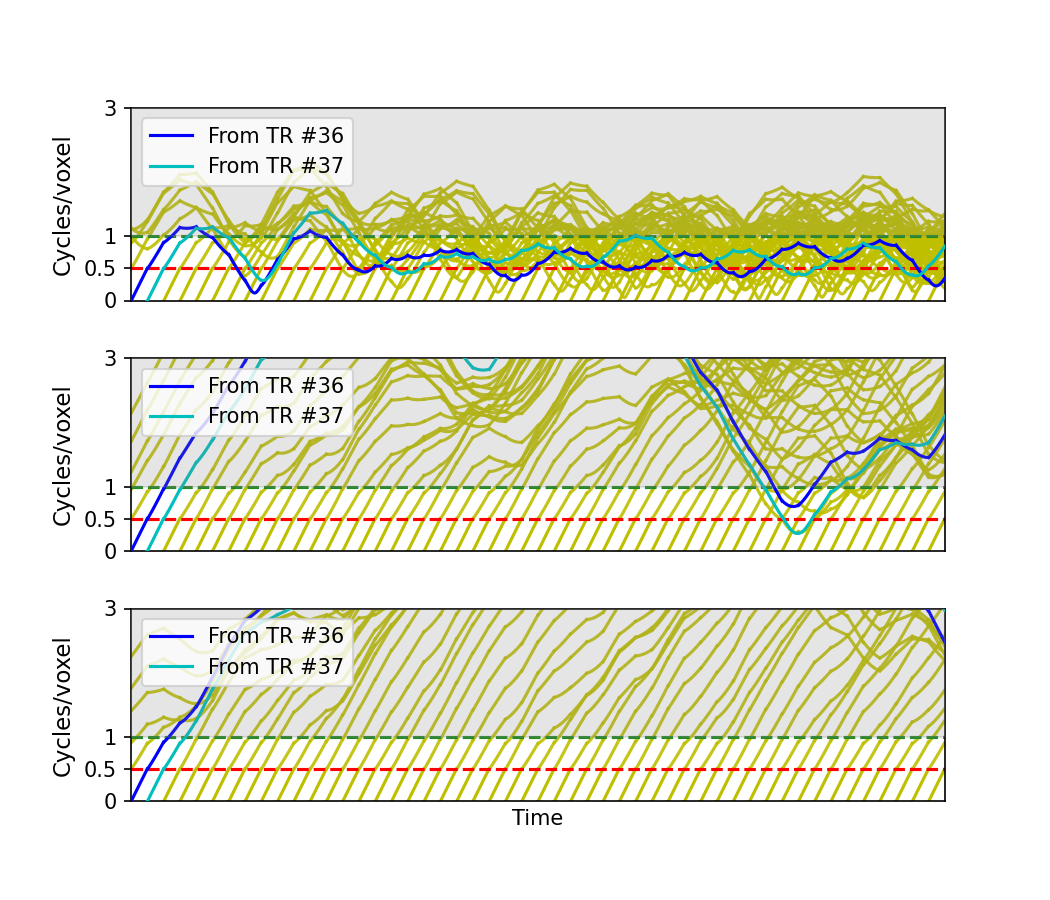

In [16]:
nSpokes_plot = 55
spoke_start_idx = 30 # start accumulating coherences for plotting
spokes_to_highlight = [5,6] # different 
start_xaxis = 5 # which TR to start xaxis for plotting

plt.figure(figsize=(8,5))
ax1 = plt.subplot(311)
ax1.set_title('Furthest endpoint thetas', loc='left')
plot_coherence_pathways_from_coords(Furthest_thetas_data.coord_radial_spokes, nSpokes_plot, spoke_start_idx, 
                                    spokes_to_highlight=spokes_to_highlight, start_xaxis=start_xaxis)

ax2 = plt.subplot(312)
ax2.set_title('Random thetas', loc='left')
plot_coherence_pathways_from_coords(Random_thetas_data.coord_radial_spokes, nSpokes_plot, spoke_start_idx, 
                                    spokes_to_highlight=spokes_to_highlight, start_xaxis=start_xaxis)

ax3 = plt.subplot(313)
ax3.set_title('Optimized thetas', loc='left')
plot_coherence_pathways_from_coords(Optim_thetas_data.coord_radial_spokes, nSpokes_plot, spoke_start_idx,
                                   spokes_to_highlight=spokes_to_highlight, start_xaxis=start_xaxis)

In [17]:
# Formatting for paper figure
def formatting_fig3(ax_list):
    
    for ax in ax_list:
        # Shading to show dephased regions
        ax.axhspan(1, 3, color='gray', alpha=0.2, zorder=102)
        ax.set_ylabel('Cycles/voxel', fontsize=11)
        ax.set_xlabel('')
        ax.set_yticklabels(labels=['0', '0.5', '1', '3'], fontsize=10)
        ax.set_title('', loc='left')
        
    fig = plt.gcf()
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    fig.set_size_inches(7,6)
    ax_list[-1].set_xlabel('Time')
    
formatting_fig3([ax1, ax2, ax3])

## Gridding reconstruction of fully-sampled acquisitions from each scheme

In [18]:
#### Furthest theta scheme ####

# Combine waspi and hires spokes
ksp_hires_waspi, coord_hires_waspi = Furthest_thetas_data.combine_waspiHires_flat()
# Gridding reconstruction
coil_ims_furthest_thetas = recon_adjoint_postcomp_coilbycoil(ksp=ksp_hires_waspi, 
                                                        coord=coord_hires_waspi, 
                                                        img_shape=img_shape, 
                                                        oversamp=2, norm="ortho")
# coil combination
im_furthest_thetas_grid = sp.rss(coil_ims_furthest_thetas, axes=0) 

#### Random theta scheme ####

# Combine waspi and hires spokes
ksp_hires_waspi, coord_hires_waspi = Random_thetas_data.combine_waspiHires_flat()
# Gridding reconstruction
coil_ims_random_thetas = recon_adjoint_postcomp_coilbycoil(ksp=ksp_hires_waspi, 
                                                        coord=coord_hires_waspi, 
                                                        img_shape=img_shape, 
                                                        oversamp=2, norm="ortho")
# coil combination
im_random_thetas_grid = sp.rss(coil_ims_random_thetas, axes=0)

#### Optimized theta scheme ####

# Combine waspi and hires spokes
ksp_hires_waspi, coord_hires_waspi = Optim_thetas_data.combine_waspiHires_flat()
# Gridding reconstruction
coil_ims_optim_thetas = recon_adjoint_postcomp_coilbycoil(ksp=ksp_hires_waspi, 
                                                        coord=coord_hires_waspi, 
                                                        img_shape=img_shape, 
                                                        oversamp=2, norm="ortho")
# coil combination
im_optim_thetas_grid = sp.rss(coil_ims_optim_thetas, axes=0)

Coil-by-coil Gridding recon: 100%|█| 12/12 [00:01<00:00,  9.25it/


Coil-by-coil recon finished


Coil-by-coil Gridding recon: 100%|█| 12/12 [00:01<00:00, 10.11it/


Coil-by-coil recon finished


Coil-by-coil Gridding recon: 100%|█| 12/12 [00:01<00:00, 10.15it/


Coil-by-coil recon finished


<IPython.core.display.Javascript object>


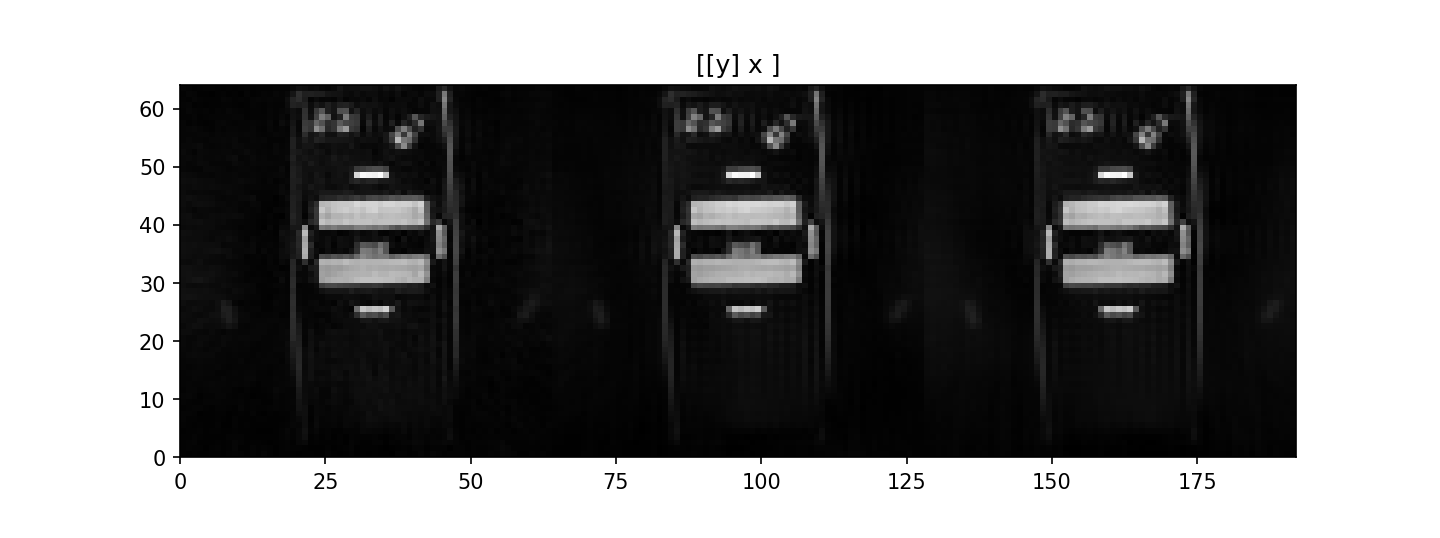

In [45]:
if not DEMO_MODE:
    slice_num = 110
    im_plot = np.stack((
                    im_furthest_thetas_grid[56:200, slice_num, 75:210],
                    im_random_thetas_grid[56:200, slice_num, 75:210], 
                    im_optim_thetas_grid[56:200, slice_num, 75:210]), axis=0
               )
else:
    slice_num = 29
    im_plot = np.concatenate((
                    im_furthest_thetas_grid[:, slice_num, :],
                    im_random_thetas_grid[:, slice_num, :], 
                    im_optim_thetas_grid[:, slice_num, :]), axis=0
               )
    
pl.ImagePlot(im_plot.T)

# Figure 4

## Load trajectories for different arc angles + radial schemes

In [64]:
opxres = 256 if not DEMO_MODE else 64
spokes_per_seg = 384
num_segs = 172
num_segs_lowres = 4

In [48]:
# Path that points to data dir with kacq files from scan
traj_files_dir = './example_traj_kacq_files/'

# golden angle rotations of Arc-ZTE segments
seg_rot_file = 'rot_txt_files/seg_golden3d_rotMats.txt' 


### ArcZTE 13 deg - calculates traj from grad kacq saved by sequence code
kacq_file = glob.glob(traj_files_dir + 'kacq_arc_zte13*')[-1]
arcZTE_13deg = Traj_ArcZTE_from_kacq(opxres, seg_rot_file, kacq_file)

### ArcZTE 53 deg - calculates traj from grad kacq saved by sequence code
kacq_file = glob.glob(traj_files_dir + 'kacq_arc_zte53*')[-1]
arcZTE_53deg = Traj_ArcZTE_from_kacq(opxres, seg_rot_file, kacq_file)

### ArcZTE 83 deg - calculates traj from grad kacq saved by sequence code
kacq_file = glob.glob(traj_files_dir + 'kacq_arc_zte83*')[-1]
arcZTE_83deg = Traj_ArcZTE_from_kacq(opxres, seg_rot_file, kacq_file)


### Standard ZTE - calculates traj from endpoints kacq saved by sequence code
endpoints_txt_path = glob.glob(traj_files_dir + 'kacq_stdzte*')[-1]
stdZTE = Traj_RadialZTE_from_kacq(opxres, endpoints_txt_path, 
                                  spokes_per_seg, num_segs_lowres)

### Phyllotaxis ZTE - calculates trajectory from formula
smoothness = 10
gm_flag = False
segsPerInterleaf = 1
phylloZTE = Traj_CalcPhyllo_ZTE(opxres, smoothness, 
                                gm_flag, segsPerInterleaf, 
                                spokes_per_seg, num_segs, 
                                num_segs_lowres)

### AZTEK - calculates traj from endpoints kacq saved by sequence code
endpoints_txt_path = glob.glob(traj_files_dir + 'kacq_aztek*')[-1]
aztekZTE = Traj_RadialZTE_from_kacq(opxres, endpoints_txt_path, 
                                    spokes_per_seg, num_segs_lowres)

# Compile all ZTE schemes into list
scheme_list = [arcZTE_13deg, arcZTE_53deg, arcZTE_83deg, 
               aztekZTE, phylloZTE, stdZTE]

## Plot coverage uniformity vs. number of spokes

In [65]:
### Calculate coverage uniformity # spokes < 1 segment
nSpokes_test = np.concatenate((np.arange(50, 360, 50), 
                              np.array([spokes_per_seg])))
cov_metrics = np.zeros((len(scheme_list), len(nSpokes_test)))
seed = 0

print(f"Calculating coverage uniformity for endpoints")
for j, scheme in enumerate(scheme_list): # loop over ZTE schemes
    
    for i, nSpk in enumerate(tqdm(nSpokes_test)): # loop over diff spokes
        cov_metrics[j, i] = cov_uniformity_metric(
                                    scheme.coord_sampl_hires[0:nSpk, -1, :], 
                                    n=nPts_covg_metric, seed=seed)        

# For larger groups of spokes, takes a few hours - don't run if in demo mode    
if not DEMO_MODE:

    ### Calculate coverage uniformity over # spokes > 1 segment
    nSpokes_test2 = np.concatenate((np.array([200]), np.arange(400, 9000, 400)))
    cov_metrics2 = np.zeros((len(scheme_list), len(nSpokes_test2)))

    print(f"Calculating coverage uniformity for endpoints")
    for j, scheme in enumerate(scheme_list): # loop over ZTE schemes
        
        for i, nSpk in enumerate(tqdm(nSpokes_test2)): # loop over diff spokes
            cov_metrics2[j, i] = cov_uniformity_metric(
                                    scheme.coord_sampl_hires[0:nSpk, -1, :], 
                                    n=nPts_covg_metric, seed=seed)

Calculating coverage uniformity for endpoints


100%|██████████████████████████████| 8/8 [00:03<00:00,  2.46it/s]


<IPython.core.display.Javascript object>


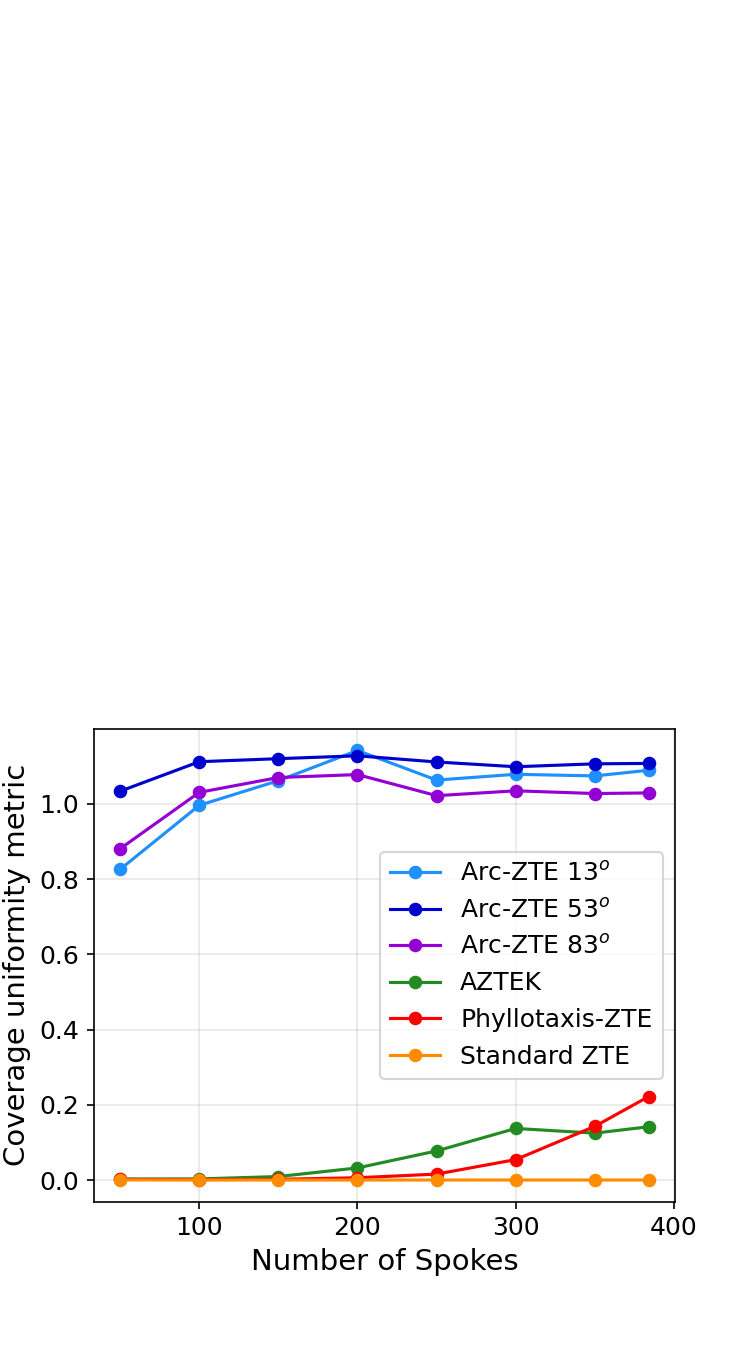

In [66]:
# Plot coverage uniformity over number of spokes for < 1 segment
plt.figure(figsize=(5,9))

#######################

ax = plt.subplot(212)
colors = ['dodgerblue', 'mediumblue',  'darkviolet']
list_angles = [13, 53, 83]

for i in range(3):
    plt.plot(nSpokes_test, cov_metrics[i, :], '.-', markersize=11, 
             label='Arc-ZTE '+ str(list_angles[i]) + '$^o$', c=colors[i])

ax.tick_params(axis='x', labelsize=12) 
ax.tick_params(axis='y', labelsize=12) 
plt.plot(nSpokes_test, cov_metrics[3, :], '.-', markersize=11, 
         label='AZTEK', c='forestgreen')
plt.plot(nSpokes_test, cov_metrics[4, :], '.-', markersize=11, 
         label='Phyllotaxis-ZTE', c='red')
plt.plot(nSpokes_test, cov_metrics[5, :], '.-', markersize=11, 
         label='Standard ZTE', c='darkorange')
plt.legend(fontsize=12)

plt.xlabel('Number of Spokes', fontsize=14)
plt.ylabel('Coverage uniformity metric', fontsize=14)
plt.grid(True, alpha=0.3)

####################

# For larger groups of spokes, takes a few hours - don't run if in demo mode
if not DEMO_MODE:

    ax2 = plt.subplot(211)
    colors = ['dodgerblue', 'mediumblue',  'darkviolet']
    for i in range(3):
        plt.plot(nSpokes_test2, cov_metrics2[i, :], '.-', markersize=11, 
                label='Arc-ZTE '+ str(list_angles[i]) + '$^o$', c=colors[i])
        
    plt.plot(nSpokes_test2, cov_metrics2[3, :], '.-', markersize=11, 
            label='AZTEK', c='forestgreen')
    plt.plot(nSpokes_test2, cov_metrics2[4, :], '.-', markersize=11, 
            label='Phyllotaxis-ZTE', c='red')
    plt.plot(nSpokes_test2, cov_metrics2[5, :], '.-', markersize=11, 
            label='Standard ZTE', c='darkorange')

    ax2.tick_params(axis='x', labelsize=12) 
    ax2.tick_params(axis='y', labelsize=12) 

    plt.legend(fontsize=12)
    plt.xlabel('Number of Spokes', fontsize=14)
    plt.ylabel('Coverage uniformity metric', fontsize=14)
    plt.grid(True, alpha=0.3)

## Plot coherence pathways

<IPython.core.display.Javascript object>


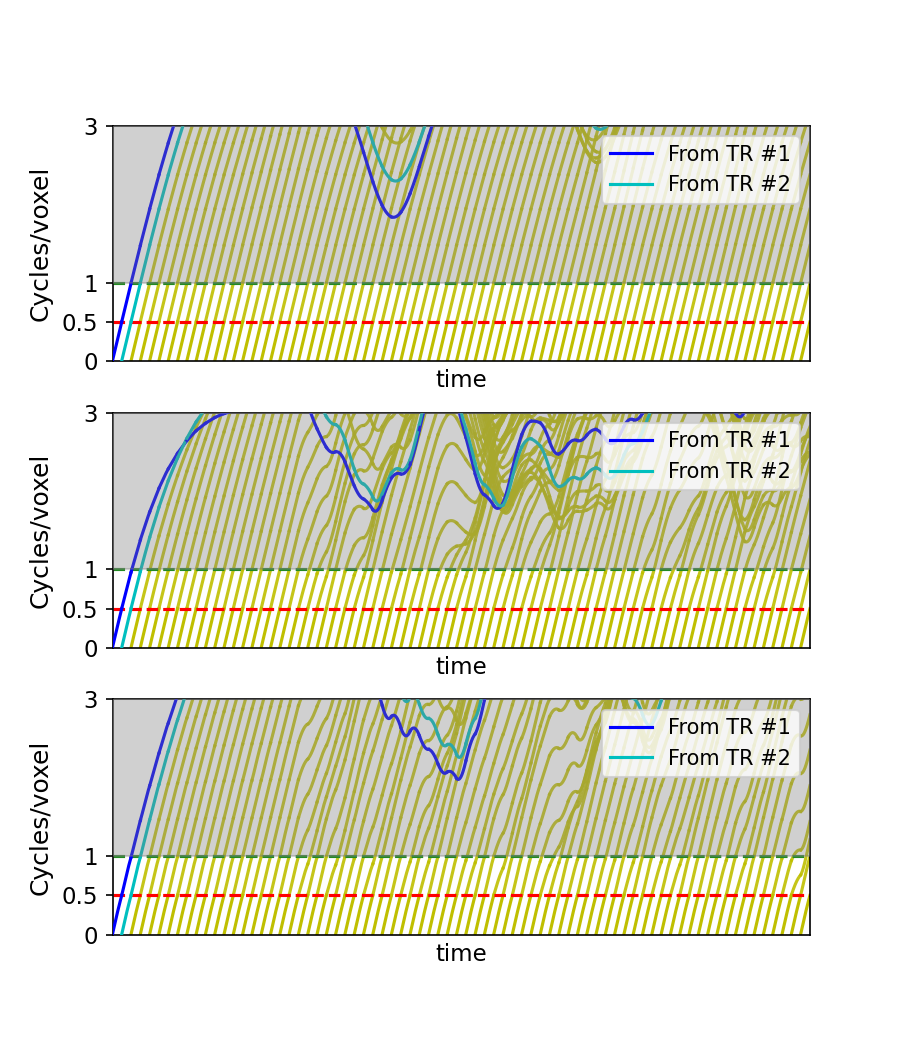

In [67]:
nSpokes_plot = 75
spoke_start_idx = 0

plt.figure(figsize=(6,6))
ax1 = plt.subplot(311)
ax1.set_title(f"Arc-ZTE 13 deg", loc='left')
plot_coherence_pathways_from_coords(arcZTE_13deg.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper right')

ax2 = plt.subplot(312)
ax2.set_title(f"Arc-ZTE 53 deg", loc='left')
plot_coherence_pathways_from_coords(arcZTE_53deg.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper right')

ax3 = plt.subplot(313)
ax3.set_title(f"Arc-ZTE 83 deg", loc='left')
plot_coherence_pathways_from_coords(arcZTE_83deg.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper right')

In [69]:
# Some formatting for paper figure
def formatting_fig4(ax_list):
    
    for ax in ax_list:
        # Shading to show regions to be ignored
        ax.axhspan(1, 3, color='gray', alpha=0.2, zorder=102)
        ax.set_xlabel('time', fontsize=11)
        ax.set_ylabel('Cycles/voxel', fontsize=12)
        ax.set_yticklabels(labels=['0', '0.5', '1', '3'], fontsize=11)
        ax.set_title('', loc='left')
        
    fig = plt.gcf()
    fig.set_size_inches(6,7)
    fig.subplots_adjust(hspace=0.22, wspace=0.3)
        
formatting_fig4([ax1, ax2, ax3])   

## Plot trajectories

In [70]:
azim = -42
elev = 8

<IPython.core.display.Javascript object>


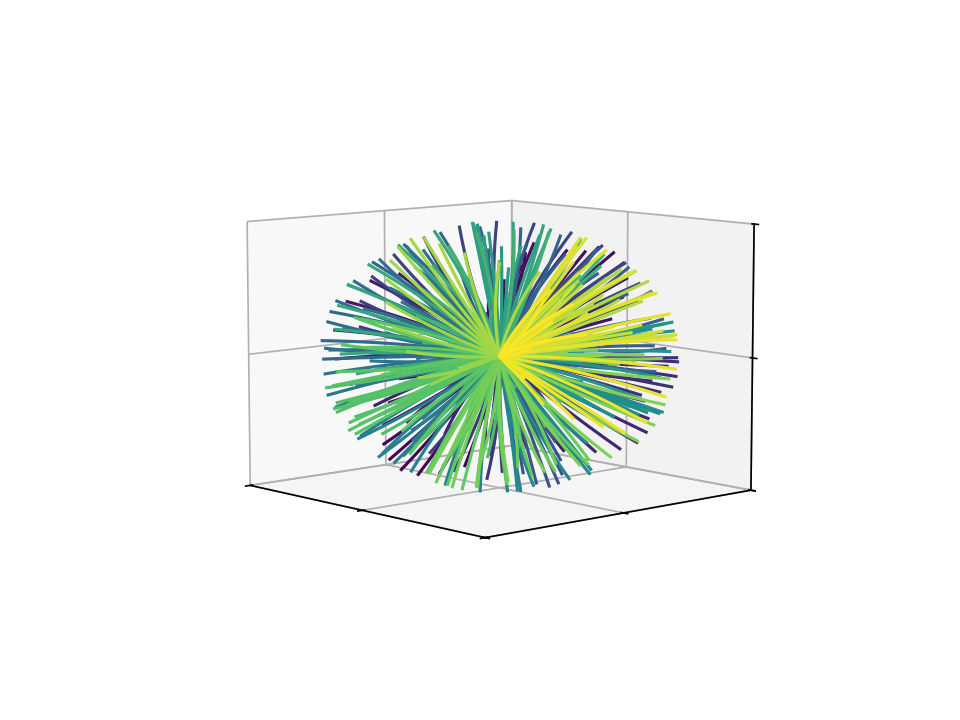

In [71]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, arcZTE_13deg.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

<IPython.core.display.Javascript object>


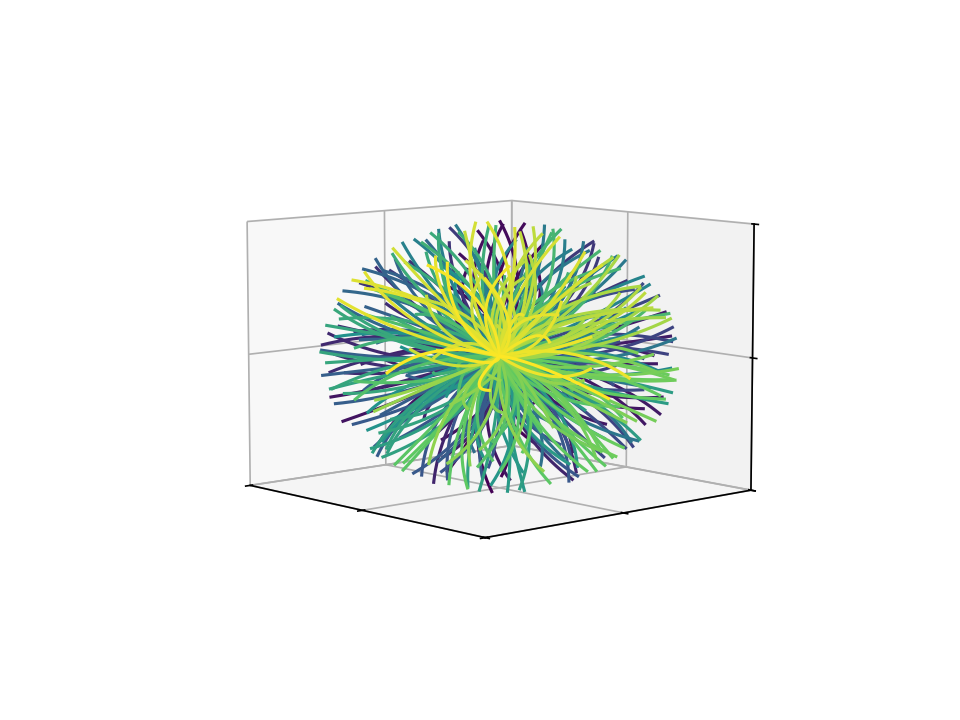

In [72]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, arcZTE_53deg.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

<IPython.core.display.Javascript object>


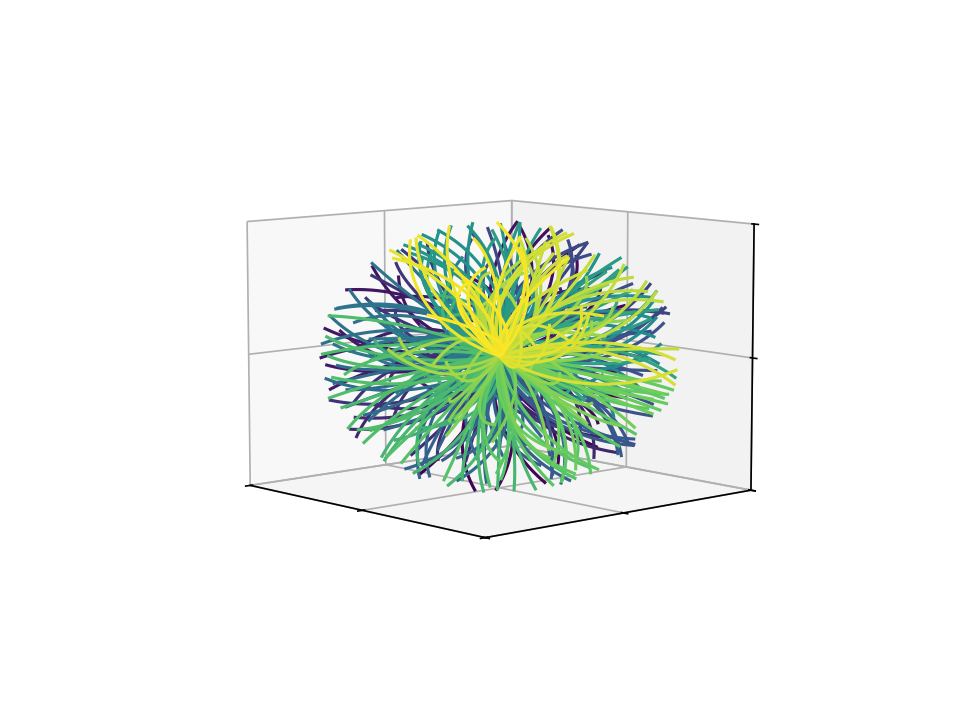

In [73]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, arcZTE_83deg.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

# Figure 5

## Calculate PSFs for number of successive spokes

In [63]:
def calc_psfs_temp_durations(TrajObj, img_shape, nSpokes_list, device_num):
    '''Function to sweep through nSpokes in nSpokes_list and calculate PSFs
    
    TrajObj: object loaded from ZTE trajectory class
    img_shage: [nx, ny, nz] for reconstruction
    nSpokes_list: list of number of spokes for testing with
    
    Returns list of PSFs and list of sidelobe-peak-ratio for each
    '''
    psfs_all = np.zeros((len(nSpokes_list), *img_shape), dtype=np.complex128) 
    sprs_all = []
    
    for i, nSpokes in enumerate(tqdm(nSpokes_list)):
        
        spokes_recon = np.arange(0, nSpokes, 1)
        coords_withWaspi = TrajObj.combine_waspiHires_flat(spokes_subset=spokes_recon)
        
        psf_single = calc_psf_coords(coords_withWaspi, img_shape, device_num)
        psfs_all[i] = psf_single
        sprs_all.append(sidelobe_to_peak_ratio(psf_single))
    
    return psfs_all, sprs_all

In [ ]:
if not DEMO_MODE:
    # Run for all test spokes if not demo mode
    nSpokes_list = np.concatenate((np.array([220]), np.arange(550, 9000, 550)))
    idx = [0, 4, 8]
else:
    nSpokes_list = np.array([200, 400, 600])
    idx = [0, 1, 2]

# Calculate PSFs and sidelobe-to-peak ratios for all comparison schemes
psfs_arc13, sprs_arc13 = calc_psfs_temp_durations(arcZTE_13deg, img_shape, nSpokes_list, device_num)
psfs_arc53, sprs_arc53 = calc_psfs_temp_durations(arcZTE_53deg, img_shape, nSpokes_list, device_num)
psfs_arc83, sprs_arc83 = calc_psfs_temp_durations(arcZTE_83deg, img_shape, nSpokes_list, device_num)

psfs_phyllo, sprs_phyllo = calc_psfs_temp_durations(phylloZTE, img_shape, nSpokes_list, device_num)
psfs_aztek, sprs_aztek = calc_psfs_temp_durations(aztekZTE, img_shape, nSpokes_list, device_num)

## Visualize PSFs in 2D and 1D

Plotting PSFs for 200, 400, 600 spokes


<IPython.core.display.Javascript object>


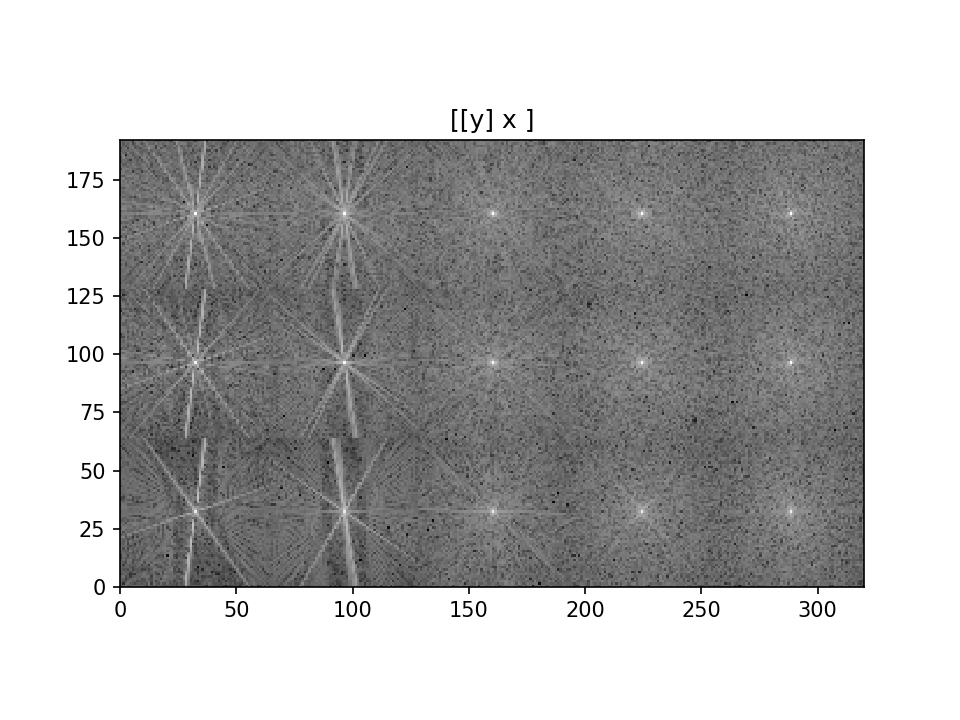

In [57]:
print(f"Plotting PSFs for {nSpokes_list[idx[0]]}, {nSpokes_list[idx[1]]}, {nSpokes_list[idx[2]]} spokes")

if DEMO_MODE:
    sl_num = 32
    size = img_shape[0]
else:
    sl_num = 128
    size = img_shape[0]
    
pl.ImagePlot(np.concatenate((abs(psfs_aztek[idx, sl_num].transpose(0,2,1).reshape(-1, size)), 
                             abs(psfs_phyllo[idx, sl_num].transpose(0,2,1).reshape(-1, size)), 
                             abs(psfs_arc13[idx, sl_num].transpose(0,2,1).reshape(-1, size)), 
                             abs(psfs_arc53[idx, sl_num].transpose(0,2,1).reshape(-1, size)), 
                             abs(psfs_arc83[idx, sl_num].transpose(0,2,1).reshape(-1, size))), axis=1))

<IPython.core.display.Javascript object>


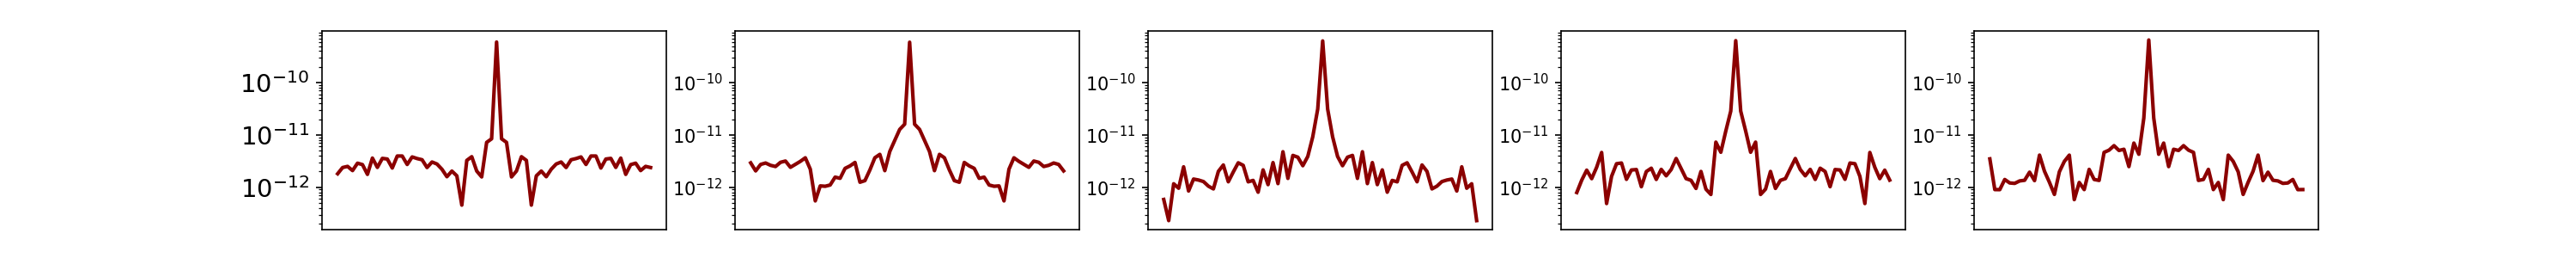

In [61]:
pl_idx = idx[2]

plt.figure(figsize=(20,2))
ax1 = plt.subplot(151)
plt.plot(abs(psfs_aztek[pl_idx, sl_num, :, sl_num]), linewidth=2, color='darkred')
plt.xticks([])
plt.yticks(fontsize=14)

ax = plt.subplot(152, sharey=ax1)
plt.plot(abs(psfs_phyllo[pl_idx, sl_num, :, sl_num]), linewidth=2, color='darkred')
plt.xticks([])
ax.set_yticklabels([])

ax = plt.subplot(153, sharey=ax1)
plt.plot(abs(psfs_arc13[pl_idx, sl_num, :, sl_num]), linewidth=2, color='darkred')
plt.xticks([])
ax.set_yticklabels([])

ax = plt.subplot(154, sharey=ax1)
plt.plot(abs(psfs_arc53[pl_idx, sl_num, :, sl_num]), linewidth=2, color='darkred')
plt.xticks([])
ax.set_yticklabels([])

ax = plt.subplot(155, sharey=ax1)
plt.plot(abs(psfs_arc83[pl_idx, sl_num, :, sl_num]), linewidth=2, color='darkred')
plt.xticks([])
ax.set_yticklabels([])

# Set the y-axis to a logarithmic scale
plt.yscale('log')

## Plot sidelobe-to-peak ratio vs. number of spokes

<IPython.core.display.Javascript object>


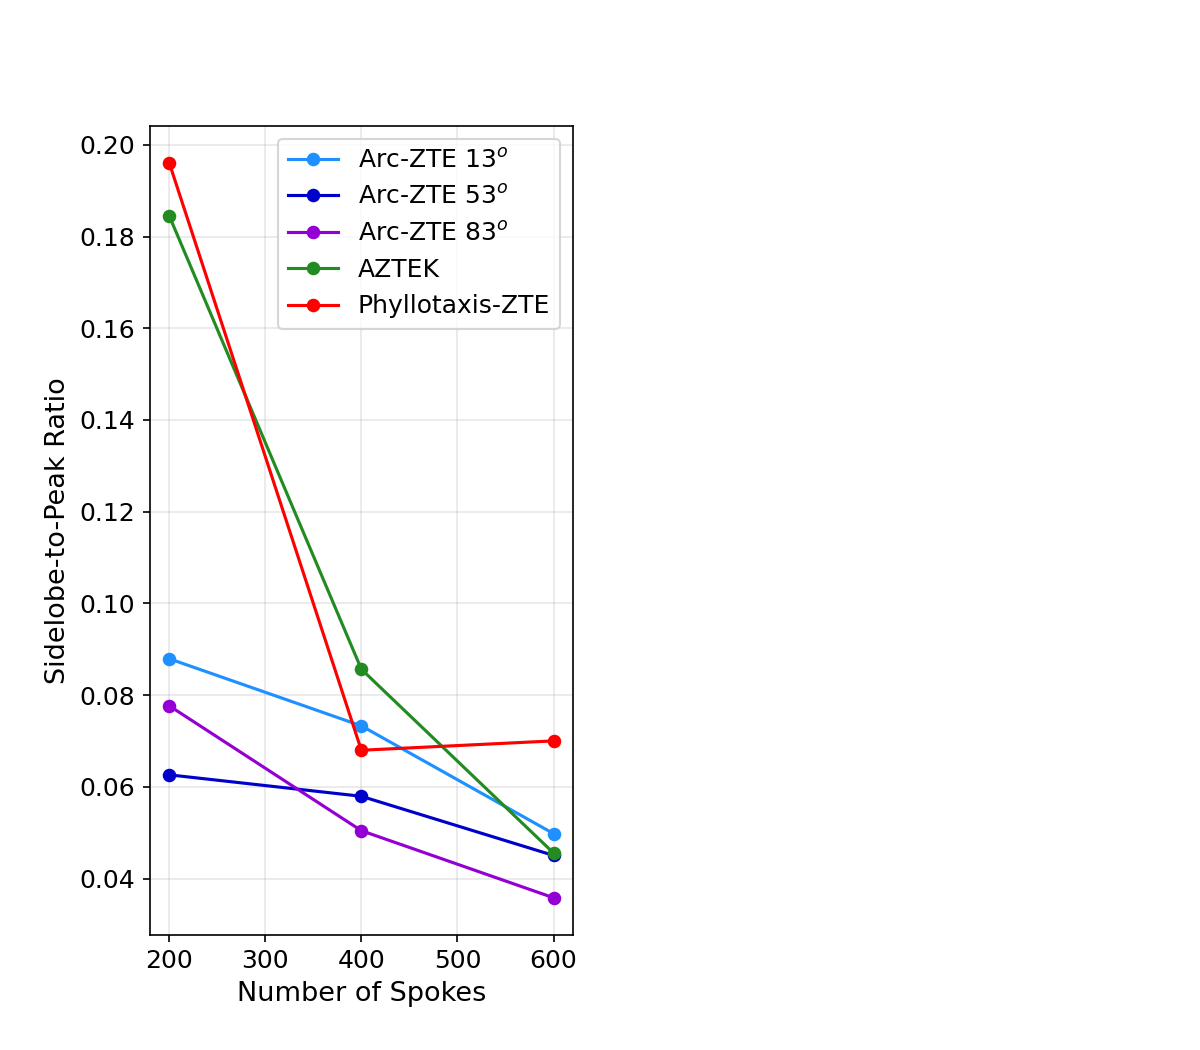

(array([100., 200., 300., 400., 500., 600., 700.]),
 [Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

In [62]:
plt.figure(figsize=(8,7))
ax1 = plt.subplot(121)

colors = ['dodgerblue', 'mediumblue',  'darkviolet', 'forestgreen', 'red', 'darkorange']
plt.plot(nSpokes_list, sprs_arc13, '.-', markersize=11,label='Arc-ZTE 13$^o$', color='dodgerblue')
plt.plot(nSpokes_list, sprs_arc53, '.-', markersize=11,label='Arc-ZTE 53$^o$', color='mediumblue')
plt.plot(nSpokes_list, sprs_arc83, '.-', markersize=11,label='Arc-ZTE 83$^o$', color='darkviolet')
plt.plot(nSpokes_list, sprs_aztek, '.-', markersize=11,label='AZTEK', color='forestgreen')
plt.plot(nSpokes_list, sprs_phyllo, '.-', markersize=11,label='Phyllotaxis-ZTE', color='red')

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylabel('Sidelobe-to-Peak Ratio', fontsize=13)
plt.yticks(fontsize=12)
plt.xlabel('Number of Spokes', fontsize=13)
plt.xticks(fontsize=12)